# Exploração — Mercado de Energia SC

Primeira etapa exploratória do projeto **Mercado Energia SC**: dados de consumo de energia elétrica por município de Santa Catarina (CELESC), 1994–2026.

Este notebook registra o caminho exploratório que levou à primeira pergunta de pesquisa: carregamento da base, reconhecimento de sua estrutura, reestruturação de **wide → long**, tratamento pontual dos valores não numéricos e primeiras agregações.

O objetivo aqui não é forçar uma análise além do que a base e esta etapa sustentam. **As decisões, descobertas e lacunas permanecem registradas no percurso**, inclusive quando algo fica para uma etapa posterior.


In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Fonte de dados

Base pública da **CELESC**, em formato *wide*: uma linha por combinação de tipo, município e classe, com colunas mensais de **1994-01 a 2026-03**.

A fonte e sua estrutura são mantidas como parte do registro da exploração. A análise desta etapa trabalha com a série disponível na própria base.


In [2]:
arquivo = "/kaggle/input/datasets/marialcsilva/santa-catarina-electricity-consumption/Municipio_Mensal_1T_2026.xlsx"

## 2. Reconhecimento da estrutura da base

Antes de transformar ou agregar os dados, foram exploradas dimensões, colunas, municípios, classes, tipos e demais campos disponíveis. Essas verificações fazem parte do percurso de descoberta da estrutura original da base.


In [3]:
os.listdir("/kaggle/input/datasets")

['marialcsilva']

In [4]:
os.listdir("/kaggle/input/datasets/marialcsilva")

['santa-catarina-electricity-consumption']

In [5]:
os.listdir("/kaggle/input/datasets/marialcsilva/santa-catarina-electricity-consumption")

['Municipio_Mensal_1T_2026.xlsx']

In [6]:
excel = pd.ExcelFile(arquivo)

In [7]:
excel.sheet_names

['Número de UC', 'Consumo MWh']

In [8]:
df = pd.read_excel(arquivo, sheet_name="Consumo MWh")

In [9]:
df.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,1994-01-01 00:00:00,1994-02-01 00:00:00,...,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,21357.147,20782.785,...,52878.556648,60441.735810,54284.838228,58371.440918,53787.994558,53800.328053,56821.529842,87456.494352,86524.998202,83895.217345
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,1698.383,1641.103,...,2558.042630,2877.644839,2557.793542,2761.337071,2972.536314,2669.177959,2677.598859,3332.905398,3222.091413,3746.075399
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,14766.175,13420.879,...,24422.064633,22060.793725,23029.908608,23087.512572,22567.306346,22916.987372,24222.198117,30172.991984,32276.237126,35388.860964
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,25.908,23.863,...,37.052000,43.193000,29.520000,37.073000,37.665,38.949800,43.244000,50.350000,33.971450,42.984200
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,6393.112,4903.650,...,6667.282925,7209.118309,6673.288946,6409.265993,6528.080709,7015.699795,6543.715033,7558.026813,8207.902689,8857.708610


In [10]:
df.shape

(7716, 395)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7716 entries, 0 to 7715
Columns: 395 entries, tipo to 2026-03-01 00:00:00
dtypes: float64(386), int64(2), object(7)
memory usage: 23.3+ MB


In [12]:
df.tail(5)

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,1994-01-01 00:00:00,1994-02-01 00:00:00,...,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00
7711,Livre,17109,ARITA,Núcleo Leste,Itajaí (sede),Piçarras,2,Industrial,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.876050
7712,Livre,3101,ARJOI,Núcleo Norte,Joinville (sede),Joinville,2,Industrial,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.477670
7713,Livre,17108,ARITA,Núcleo Leste,Itajaí (sede),Barra Velha,2,Industrial,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.091900
7714,Livre,17110,ARITA,Núcleo Leste,Itajaí (sede),Penha,2,Industrial,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.759996
7715,Livre,7101,ARJSL,Núcleo Norte,Jaraguá do Sul (unidade),Jaraguá do Sul,2,Industrial,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.607623


In [13]:
df.columns

Index([             'tipo',          'cod_muni',           'agência',
                  'núcleo',           'unidade',         'município',
              'cod_classe',            'classe', 1994-01-01 00:00:00,
       1994-02-01 00:00:00,
       ...
       2025-06-01 00:00:00, 2025-07-01 00:00:00, 2025-08-01 00:00:00,
       2025-09-01 00:00:00, 2025-10-01 00:00:00, 2025-11-01 00:00:00,
       2025-12-01 00:00:00, 2026-01-01 00:00:00, 2026-02-01 00:00:00,
       2026-03-01 00:00:00],
      dtype='object', length=395)

In [14]:
df["município"].nunique()

290

In [15]:
df["município"].unique()

array(['Florianópolis', 'São José', 'Palhoça',
       'Santo Amaro da Imperatriz', 'Águas Mornas', 'Biguaçu',
       'Antônio Carlos', 'Governador Celso Ramos', 'Tijucas', 'Canelinha',
       'São João Batista', 'Major Gercino', 'Nova Trento', 'Angelina',
       'Rancho Queimado', 'São Pedro de Alcântara', 'Alfredo Wagner',
       'Blumenau', 'Brusque', 'Guabiruba', 'Pomerode', 'Gaspar', 'Timbó',
       'Rio dos Cedros', 'Benedito Novo', 'Indaial', 'Rodeio', 'Ascurra',
       'Luiz Alves', 'Botuverá', 'Massaranduba', 'Apiúna',
       'Doutor Pedrinho', 'Joinville', 'Garuva', 'Araquari',
       'São Francisco do Sul', 'Itapoá', 'Balneário Barra do Sul',
       'Lages', 'São José do Cerrito', 'São Joaquim',
       'Bom Jardim da Serra', 'Urubici', 'Bom Retiro', 'Ponte Alta',
       'Curitibanos', 'Santa Cecília', 'Campo Belo do Sul',
       'Anita Garibaldi', 'Correia Pinto', 'Otacílio Costa', 'Urupema',
       'Celso Ramos', 'Rio Rufino', 'Cerro Negro', 'São Cristóvão do Sul',
       'P

In [16]:
df["classe"].value_counts()

classe
Industrial            2696
Comercial             2591
Revenda                477
Serviço Público        455
Rural                  326
Poder Público          301
Residencial            290
Iluminação Pública     290
Próprio                290
Name: count, dtype: int64

In [17]:
df["tipo"].value_counts()

tipo
Livre     5106
Cativo    2610
Name: count, dtype: int64

In [18]:
df["agência"].value_counts()

agência
ARBLU    984
ARFLO    952
ARITA    686
ARJOI    678
ARCHA    612
ARCRI    554
ARRSL    475
ARSMO    451
ARLAG    426
ARTUB    399
ARJOA    292
ARVID    288
ARJSL    266
ARCON    259
ARMAF    245
ARSBS    149
Name: count, dtype: int64

In [19]:
df.groupby("município").size().sort_values(ascending=False)

município
Joinville                 486
Florianópolis             335
Blumenau                  274
Itajaí                    215
Brusque                   175
                         ... 
Belmonte                    9
Tigrinhos                   9
São Pedro de Alcântara      9
Tunápolis                   9
Treze de Maio               9
Length: 290, dtype: int64

In [20]:
df[df["município"] == "Joinville"][["município", "classe", "tipo"]]

,município,classe,tipo
297,Joinville,Residencial,Cativo
298,Joinville,Industrial,Cativo
299,Joinville,Comercial,Cativo
300,Joinville,Rural,Cativo
301,Joinville,Poder Público,Cativo
...,...,...,...
7688,Joinville,Comercial,Livre
7695,Joinville,Comercial,Livre
7708,Joinville,Comercial,Livre
7709,Joinville,Comercial,Livre


In [21]:
df[df["município"] == "Belmonte"][["município", "classe", "tipo"]]

,município,classe,tipo
1458,Belmonte,Residencial,Cativo
1459,Belmonte,Industrial,Cativo
1460,Belmonte,Comercial,Cativo
1461,Belmonte,Rural,Cativo
1462,Belmonte,Poder Público,Cativo
1463,Belmonte,Iluminação Pública,Cativo
1464,Belmonte,Serviço Público,Cativo
1465,Belmonte,Próprio,Cativo
1466,Belmonte,Revenda,Cativo


In [22]:
df[df["município"] == "Joinville"][["classe", "tipo"]].drop_duplicates()

,classe,tipo
297,Residencial,Cativo
298,Industrial,Cativo
299,Comercial,Cativo
300,Rural,Cativo
301,Poder Público,Cativo
302,Iluminação Pública,Cativo
303,Serviço Público,Cativo
304,Próprio,Cativo
305,Revenda,Cativo
2612,Industrial,Livre


In [23]:
df[df["município"] == "Belmonte"][["classe", "tipo"]].drop_duplicates()

,classe,tipo
1458,Residencial,Cativo
1459,Industrial,Cativo
1460,Comercial,Cativo
1461,Rural,Cativo
1462,Poder Público,Cativo
1463,Iluminação Pública,Cativo
1464,Serviço Público,Cativo
1465,Próprio,Cativo
1466,Revenda,Cativo


In [24]:
df[df["município"] == "Joinville"]["unidade"].value_counts()

unidade
Joinville (sede)    486
Name: count, dtype: int64

In [25]:
df[df["município"] == "Joinville"]["núcleo"].value_counts()

núcleo
Núcleo Norte    486
Name: count, dtype: int64

In [26]:
df.columns.tolist()

['tipo',
 'cod_muni',
 'agência',
 'núcleo',
 'unidade',
 'município',
 'cod_classe',
 'classe',
 datetime.datetime(1994, 1, 1, 0, 0),
 datetime.datetime(1994, 2, 1, 0, 0),
 datetime.datetime(1994, 3, 1, 0, 0),
 datetime.datetime(1994, 4, 1, 0, 0),
 datetime.datetime(1994, 5, 1, 0, 0),
 datetime.datetime(1994, 6, 1, 0, 0),
 datetime.datetime(1994, 7, 1, 0, 0),
 datetime.datetime(1994, 8, 1, 0, 0),
 datetime.datetime(1994, 9, 1, 0, 0),
 datetime.datetime(1994, 10, 1, 0, 0),
 datetime.datetime(1994, 11, 1, 0, 0),
 datetime.datetime(1994, 12, 1, 0, 0),
 datetime.datetime(1995, 1, 1, 0, 0),
 datetime.datetime(1995, 2, 1, 0, 0),
 datetime.datetime(1995, 3, 1, 0, 0),
 datetime.datetime(1995, 4, 1, 0, 0),
 datetime.datetime(1995, 5, 1, 0, 0),
 datetime.datetime(1995, 6, 1, 0, 0),
 datetime.datetime(1995, 7, 1, 0, 0),
 datetime.datetime(1995, 8, 1, 0, 0),
 datetime.datetime(1995, 9, 1, 0, 0),
 datetime.datetime(1995, 10, 1, 0, 0),
 datetime.datetime(1995, 11, 1, 0, 0),
 datetime.datetime(1995,

In [27]:
df[df["município"] == "Joinville"].nunique()

tipo                     2
cod_muni                 1
agência                  1
núcleo                   1
unidade                  1
                      ... 
2025-11-01 00:00:00    435
2025-12-01 00:00:00    439
2026-01-01 00:00:00    449
2026-02-01 00:00:00    455
2026-03-01 00:00:00    467
Length: 395, dtype: int64

In [28]:
df[["tipo", "município", "classe"]].drop_duplicates()

,tipo,município,classe
0,Cativo,Florianópolis,Residencial
1,Cativo,Florianópolis,Industrial
2,Cativo,Florianópolis,Comercial
3,Cativo,Florianópolis,Rural
4,Cativo,Florianópolis,Poder Público
...,...,...,...
7533,Livre,Joinville,Poder Público
7544,Livre,Celso Ramos,Industrial
7569,Livre,Correia Pinto,Serviço Público
7644,Livre,Piratuba,Serviço Público


In [29]:
df[["tipo", "município", "classe", "agência"]].drop_duplicates()

,tipo,município,classe,agência
0,Cativo,Florianópolis,Residencial,ARFLO
1,Cativo,Florianópolis,Industrial,ARFLO
2,Cativo,Florianópolis,Comercial,ARFLO
3,Cativo,Florianópolis,Rural,ARFLO
4,Cativo,Florianópolis,Poder Público,ARFLO
...,...,...,...,...
7533,Livre,Joinville,Poder Público,ARJOI
7544,Livre,Celso Ramos,Industrial,ARLAG
7569,Livre,Correia Pinto,Serviço Público,ARLAG
7644,Livre,Piratuba,Serviço Público,ARJOA


In [30]:
df[["tipo", "município", "classe", "agência", "núcleo"]].drop_duplicates()

,tipo,município,classe,agência,núcleo
0,Cativo,Florianópolis,Residencial,ARFLO,Núcleo Grande Capital
1,Cativo,Florianópolis,Industrial,ARFLO,Núcleo Grande Capital
2,Cativo,Florianópolis,Comercial,ARFLO,Núcleo Grande Capital
3,Cativo,Florianópolis,Rural,ARFLO,Núcleo Grande Capital
4,Cativo,Florianópolis,Poder Público,ARFLO,Núcleo Grande Capital
...,...,...,...,...,...
7533,Livre,Joinville,Poder Público,ARJOI,Núcleo Norte
7544,Livre,Celso Ramos,Industrial,ARLAG,Núcleo Planalto
7569,Livre,Correia Pinto,Serviço Público,ARLAG,Núcleo Planalto
7644,Livre,Piratuba,Serviço Público,ARJOA,Núcleo Meio Oeste


In [31]:
df.groupby(["tipo", "município", "classe"]).size().sort_values(ascending=False)

tipo    município      classe     
Livre   Florianópolis  Comercial      278
        Joinville      Industrial     230
                       Comercial      227
        Blumenau       Comercial      143
        São José       Comercial      136
                                     ... 
Cativo  Irati          Próprio          1
                       Residencial      1
                       Revenda          1
                       Rural            1
        Irani          Próprio          1
Length: 3086, dtype: int64

In [32]:
df[df["município"] == "Florianópolis"]["unidade"].unique()

array(['Florianópolis (sede)'], dtype=object)

In [33]:
df[df["município"] == "Florianópolis"]["unidade"].nunique()

1

In [34]:
df[df["município"] == "Florianópolis"]["agência"].unique()

array(['ARFLO'], dtype=object)

In [35]:
for coluna in df.columns:
    print(coluna)

tipo
cod_muni
agência
núcleo
unidade
município
cod_classe
classe
1994-01-01 00:00:00
1994-02-01 00:00:00
1994-03-01 00:00:00
1994-04-01 00:00:00
1994-05-01 00:00:00
1994-06-01 00:00:00
1994-07-01 00:00:00
1994-08-01 00:00:00
1994-09-01 00:00:00
1994-10-01 00:00:00
1994-11-01 00:00:00
1994-12-01 00:00:00
1995-01-01 00:00:00
1995-02-01 00:00:00
1995-03-01 00:00:00
1995-04-01 00:00:00
1995-05-01 00:00:00
1995-06-01 00:00:00
1995-07-01 00:00:00
1995-08-01 00:00:00
1995-09-01 00:00:00
1995-10-01 00:00:00
1995-11-01 00:00:00
1995-12-01 00:00:00
1996-01-01 00:00:00
1996-02-01 00:00:00
1996-03-01 00:00:00
1996-04-01 00:00:00
1996-05-01 00:00:00
1996-06-01 00:00:00
1996-07-01 00:00:00
1996-08-01 00:00:00
1996-09-01 00:00:00
1996-10-01 00:00:00
1996-11-01 00:00:00
1996-12-01 00:00:00
1997-01-01 00:00:00
1997-02-01 00:00:00
1997-03-01 00:00:00
1997-04-01 00:00:00
1997-05-01 00:00:00
1997-06-01 00:00:00
1997-07-01 00:00:00
1997-08-01 00:00:00
1997-09-01 00:00:00
1997-10-01 00:00:00
1997-11-01 00:0

## 3. Reestruturação para formato long

O dado vem em formato *wide* (uma coluna por mês). Para permitir análise temporal e agregações, ele é convertido para *long*: cada linha passa a representar uma observação de **local + classe + mês + consumo**.

A transformação altera a forma de organização do dado, não o seu conteúdo.


In [36]:
id_vars = [
    "tipo",
    "cod_muni",
    "agência",
    "núcleo",
    "unidade",
    "município",
    "cod_classe",
    "classe",
]

In [37]:
df_long = df.melt(id_vars=id_vars, var_name="data", value_name="consumo_mwh")

In [38]:
df_long.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,data,consumo_mwh
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,1994-01-01 00:00:00,21357.147
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,1994-01-01 00:00:00,1698.383
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,1994-01-01 00:00:00,14766.175
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,1994-01-01 00:00:00,25.908
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,1994-01-01 00:00:00,6393.112


# 4. Pergunta de Pesquisa 1

## Como o consumo de energia elétrica está distribuído entre os municípios de Santa Catarina?

### Motivação

Esta é a primeira pergunta central definida no projeto. Ela parte da própria estrutura da base e procura estabelecer uma visão inicial da concentração do consumo entre os municípios, antes de avançar para a dimensão temporal.


In [39]:
df_long.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,data,consumo_mwh
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,1994-01-01 00:00:00,21357.147
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,1994-01-01 00:00:00,1698.383
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,1994-01-01 00:00:00,14766.175
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,1994-01-01 00:00:00,25.908
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,1994-01-01 00:00:00,6393.112


In [40]:
df_long["consumo_mwh"].dtype

dtype('O')

In [41]:
df_long["consumo_mwh"].sample(20)

910222        NaN
503423     28.837
1834876       NaN
852687        0.0
2220231       NaN
317495      4.955
1236718     0.215
2552614       NaN
1498207     0.349
2091949    19.956
988042       0.05
1332284       NaN
997422     53.745
1402961       NaN
1010488       NaN
1119852       0.0
815002        NaN
1118284       NaN
2491718       NaN
561083        NaN
Name: consumo_mwh, dtype: object

In [42]:
df_long["consumo_mwh"].apply(type).value_counts()

consumo_mwh
<class 'float'>    2985404
<class 'int'>          687
<class 'str'>            1
Name: count, dtype: int64

In [43]:
df_long.loc[
    df_long["consumo_mwh"].apply(lambda x: isinstance(x, str)),
    ["município", "classe", "tipo", "data", "consumo_mwh"],
]

,município,classe,tipo,data,consumo_mwh
2941381,Marmeleiro,Industrial,Cativo,2025-10-01 00:00:00,cccccc


In [44]:
df_long.loc[2941375:2941385]

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,data,consumo_mwh
2941375,Cativo,11139,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Cunhataí,5,Poder Público,2025-10-01 00:00:00,1.675
2941376,Cativo,11139,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Cunhataí,6,Iluminação Pública,2025-10-01 00:00:00,0.058362
2941377,Cativo,11139,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Cunhataí,7,Serviço Público,2025-10-01 00:00:00,5.113
2941378,Cativo,11139,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Cunhataí,8,Próprio,2025-10-01 00:00:00,0
2941379,Cativo,11139,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Cunhataí,9,Revenda,2025-10-01 00:00:00,0
2941380,Cativo,11141,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Marmeleiro,1,Residencial,2025-10-01 00:00:00,1.154
2941381,Cativo,11141,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Marmeleiro,2,Industrial,2025-10-01 00:00:00,cccccc
2941382,Cativo,11141,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Marmeleiro,3,Comercial,2025-10-01 00:00:00,6.543845
2941383,Cativo,11141,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Marmeleiro,4,Rural,2025-10-01 00:00:00,3.246
2941384,Cativo,11141,ARSMO,Núcleo Oeste,São Miguel do Oeste (unidade),Marmeleiro,5,Poder Público,2025-10-01 00:00:00,NaN


### Tratamento da coluna `consumo_mwh`

Durante a exploração da estrutura *long*, foram encontrados valores que não estavam representados como números. O tratamento abaixo converte a coluna para formato numérico e transforma os valores não convertíveis em `NaN`.

Esta é uma decisão de **tratamento desta etapa exploratória**, não uma limpeza definitiva da base.


In [45]:
df_long["consumo_mwh"] = pd.to_numeric(df_long["consumo_mwh"], errors="coerce")

In [46]:
df_long["consumo_mwh"].dtype

dtype('float64')

In [47]:
df_long["consumo_mwh"].isna().sum()

np.int64(1248009)

Os valores não numéricos identificados acima viraram `NaN` após a conversão. Eles permanecem registrados como ausentes nesta etapa exploratória.

As agregações por soma realizadas a seguir não incorporam esses valores ausentes. Isso permite prosseguir com a exploração, mas **não resolve a origem nem o significado desses valores**. O tratamento formal dos ausentes fica como lacuna para uma etapa posterior de limpeza e validação.


In [48]:
consumo_municipio = (
    df_long.groupby("município")["consumo_mwh"].sum().sort_values(ascending=False)
)

consumo_municipio.head(10)

município
Joinville         7.366386e+07
Florianópolis     3.449381e+07
Blumenau          3.335744e+07
Jaraguá do Sul    1.923137e+07
Chapecó           1.811047e+07
Itajaí            1.790081e+07
Brusque           1.596992e+07
Criciúma          1.564726e+07
São José          1.343145e+07
Caçador           1.078823e+07
Name: consumo_mwh, dtype: float64

In [49]:
consumo_municipio.head(20)

município
Joinville             7.366386e+07
Florianópolis         3.449381e+07
Blumenau              3.335744e+07
Jaraguá do Sul        1.923137e+07
Chapecó               1.811047e+07
Itajaí                1.790081e+07
Brusque               1.596992e+07
Criciúma              1.564726e+07
São José              1.343145e+07
Caçador               1.078823e+07
Lages                 1.021806e+07
Balneário Camboriú    9.805522e+06
Tubarão               9.134962e+06
Concórdia             8.620788e+06
Três Barras           8.102760e+06
Palhoça               8.085546e+06
São Bento do Sul      7.761424e+06
Braço do Norte        7.630469e+06
Indaial               7.590013e+06
Videira               7.207628e+06
Name: consumo_mwh, dtype: float64

In [50]:
consumo_municipio.describe()

count    2.900000e+02
mean     2.120089e+06
std      5.805621e+06
min      0.000000e+00
25%      1.922392e+05
50%      4.777811e+05
75%      1.609435e+06
max      7.366386e+07
Name: consumo_mwh, dtype: float64

<Axes: >

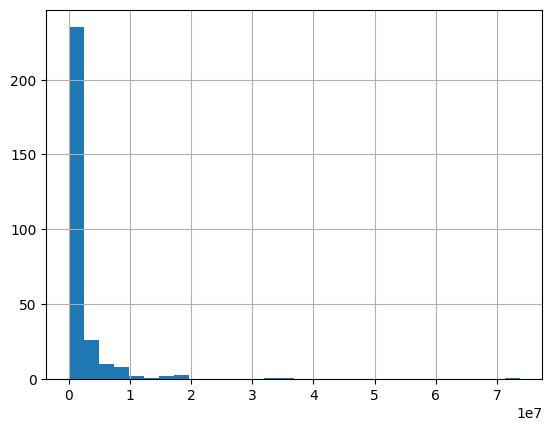

In [51]:
consumo_municipio.hist(bins=30)

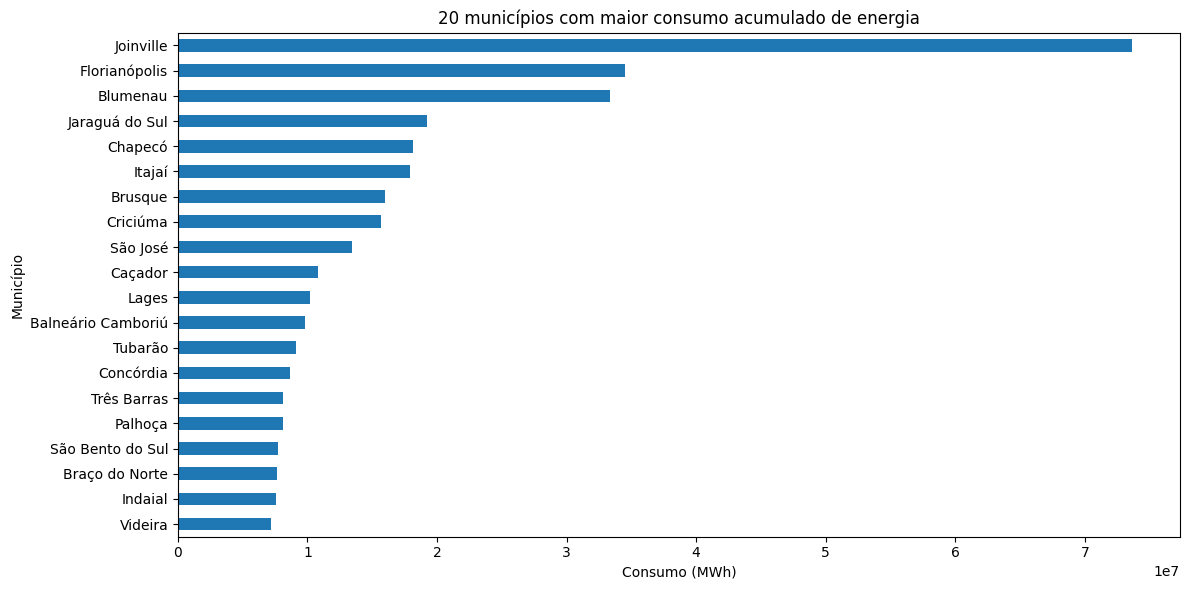

In [52]:
import matplotlib.pyplot as plt

top20 = consumo_municipio.head(20)

plt.figure(figsize=(12, 6))

top20.sort_values().plot(kind="barh")

plt.title("20 municípios com maior consumo acumulado de energia")
plt.xlabel("Consumo (MWh)")
plt.ylabel("Município")

plt.tight_layout()
plt.show()

## Primeiras observações

O ranking mostra que poucos municípios concentram grande parte do consumo de energia elétrica na série analisada.

Joinville apresenta o maior consumo acumulado, seguido por Florianópolis e Blumenau. A partir daqui, a análise passa a olhar a distribuição do consumo por outras dimensões já existentes na própria base, sem atribuir causalidade a fatores externos que ainda não foram analisados.

A concentração observada constitui a primeira evidência para a pergunta de pesquisa e orienta as investigações seguintes.


## Investigação 1.1 — Qual classe de consumo concentra a maior demanda de energia?


In [53]:
consumo_classe = (
    df_long.groupby("classe")["consumo_mwh"].sum().sort_values(ascending=False)
)

consumo_classe

classe
Industrial            2.608849e+08
Residencial           1.448805e+08
Comercial             9.533280e+07
Rural                 4.035880e+07
Revenda               3.716981e+07
Iluminação Pública    1.582907e+07
Poder Público         1.075193e+07
Serviço Público       9.190330e+06
Próprio               4.276953e+05
Name: consumo_mwh, dtype: float64

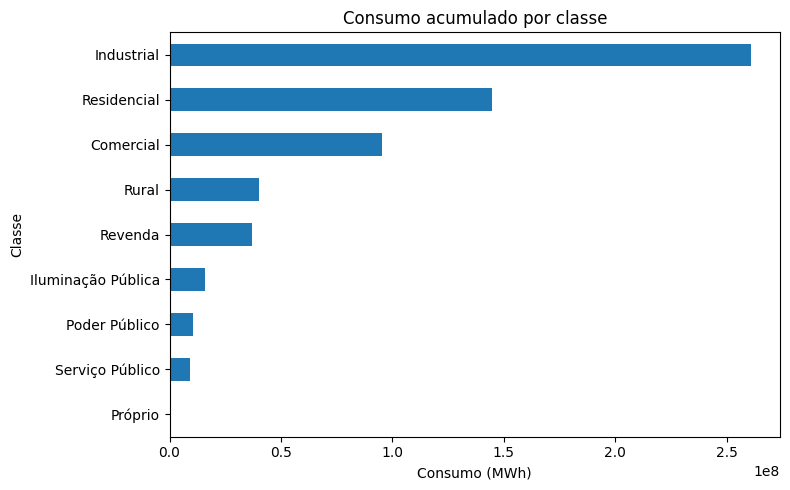

In [54]:
plt.figure(figsize=(8, 5))

consumo_classe.sort_values().plot(kind="barh")

plt.title("Consumo acumulado por classe")
plt.xlabel("Consumo (MWh)")
plt.ylabel("Classe")

plt.tight_layout()
plt.show()

### Interpretação

A análise por classe mostra que o **consumo industrial representa a maior parcela** da demanda de energia elétrica na série analisada. Em seguida aparecem as classes Residencial e Comercial.

Esse resultado descreve a composição observada na própria base. A relação entre esse padrão e características econômicas específicas dos municípios é uma hipótese de contexto, não uma relação causal demonstrada por este notebook.

Por isso, nesta etapa, a conclusão é mantida no nível que os dados sustentam: **a classe Industrial concentra o maior volume acumulado entre as classes disponíveis**.


## Investigação 1.2 — Como o consumo está distribuído entre os mercados Cativo e Livre?

A base distingue os registros entre Cativo e Livre. Nesta primeira pergunta, a comparação é feita sobre o consumo acumulado da série, como uma visão geral da composição do mercado.

A dimensão temporal ainda não é analisada aqui. Ela será objeto da próxima etapa do projeto.

In [55]:
consumo_tipo = df_long.groupby("tipo")["consumo_mwh"].sum().sort_values(ascending=False)

consumo_tipo

tipo
Cativo    4.644911e+08
Livre     1.503347e+08
Name: consumo_mwh, dtype: float64

### Interpretação

O consumo acumulado mostra que o **mercado Cativo representa a maior parcela** da demanda de energia elétrica na série histórica analisada.

O mercado Livre, embora menor em volume total, também apresenta participação relevante. A análise municipal mostra ainda que sua participação relativa não é igual em todos os municípios.

Nesta etapa, o dado permite afirmar a diferença de composição entre Cativo e Livre e identificar municípios com maior participação relativa do Livre. **Não é objetivo desta análise atribuir essa composição a uma causa econômica específica.**


In [56]:
consumo_municipio_tipo = (
    df_long.groupby(["município", "tipo"])["consumo_mwh"].sum().unstack(fill_value=0)
)

consumo_municipio_tipo.head()

tipo,Cativo,Livre
município,,
Abdon Batista,113495.595016,0.000000
Abelardo Luz,745976.084048,195923.910464
Agrolândia,637144.142624,153758.814365
Agronômica,277498.079737,2823.124685
Alfredo Wagner,382387.326205,65.982068


In [57]:
consumo_municipio_tipo["Livre"].sort_values(ascending=False).head(20)

município
Joinville               2.924179e+07
Jaraguá do Sul          6.978691e+06
Blumenau                6.817877e+06
Três Barras             5.335347e+06
Caçador                 4.944895e+06
Chapecó                 4.549164e+06
Criciúma                3.899852e+06
Correia Pinto           3.553224e+06
Xanxerê                 3.499012e+06
São Francisco do Sul    3.145100e+06
Brusque                 3.113742e+06
Concórdia               3.096836e+06
Itajaí                  2.816890e+06
Indaial                 2.636306e+06
Videira                 2.322904e+06
Otacílio Costa          2.196885e+06
Fraiburgo               2.023871e+06
Lages                   2.022447e+06
Florianópolis           1.968171e+06
São Bento do Sul        1.925754e+06
Name: Livre, dtype: float64

In [58]:
consumo_municipio_tipo["Cativo"].sort_values(ascending=False).head(20)

município
Joinville             4.442207e+07
Florianópolis         3.252564e+07
Blumenau              2.653956e+07
Itajaí                1.508392e+07
Chapecó               1.356130e+07
Brusque               1.285618e+07
Jaraguá do Sul        1.225268e+07
São José              1.216045e+07
Criciúma              1.174741e+07
Balneário Camboriú    9.577033e+06
Lages                 8.195618e+06
Tubarão               7.747910e+06
Palhoça               7.622191e+06
Braço do Norte        6.408046e+06
Forquilhinha          6.365230e+06
Caçador               5.843336e+06
São Bento do Sul      5.835670e+06
Concórdia             5.523952e+06
Gaspar                5.098795e+06
Indaial               4.953707e+06
Name: Cativo, dtype: float64

In [59]:
participacao = consumo_municipio_tipo.copy()

participacao["% Livre"] = (
    participacao["Livre"] / (participacao["Livre"] + participacao["Cativo"])
) * 100

participacao.sort_values("% Livre", ascending=False).head(20)

tipo,Cativo,Livre,% Livre
município,,,
Vidal Ramos,3.038295e+05,1.211016e+06,79.943200
Correia Pinto,1.558044e+06,3.553224e+06,69.517465
Três Barras,2.767413e+06,5.335347e+06,65.846046
Xanxerê,2.200214e+06,3.499012e+06,61.394515
Vargem Bonita,6.934126e+05,9.313536e+05,57.322315
Otacílio Costa,1.747591e+06,2.196885e+06,55.695234
Botuverá,9.072686e+05,1.102628e+06,54.859940
Treze Tílias,7.675246e+05,7.242034e+05,48.547952
Ipuaçu,1.950542e+05,1.710322e+05,46.719073


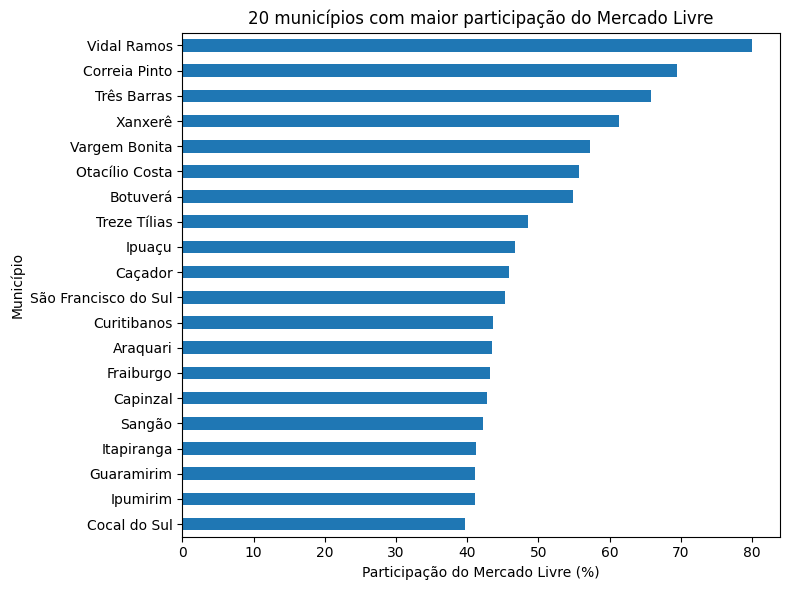

In [60]:
plt.figure(figsize=(8, 6))

participacao["% Livre"].sort_values(ascending=False).head(20).plot(kind="barh")

plt.title("20 municípios com maior participação do Mercado Livre")
plt.xlabel("Participação do Mercado Livre (%)")
plt.ylabel("Município")

plt.gca().invert_yaxis()  # coloca o maior no topo

plt.tight_layout()
plt.show()

## Conclusão da Pergunta de Pesquisa 1

A investigação mostrou que a distribuição do consumo de energia elétrica em Santa Catarina apresenta padrões diferentes quando observada sob perspectivas distintas.

O consumo acumulado evidencia uma forte concentração em poucos municípios, com **Joinville, Florianópolis e Blumenau** entre os maiores volumes observados na série.

Ao observar a composição entre os mercados Cativo e Livre, o cenário se torna mais diverso: municípios de menor volume absoluto aparecem entre aqueles com maior **participação percentual do Mercado Livre**, como Vidal Ramos, Correia Pinto, Três Barras e Xanxerê.

Esse resultado é importante porque mostra que **volume absoluto e composição do consumo são dimensões diferentes**. O primeiro evidencia a concentração do consumo entre municípios; o segundo revela diferenças na estrutura desse consumo.

### O que esta etapa responde

A primeira pergunta pode ser considerada respondida no escopo proposto: o consumo está concentrado em poucos municípios, e essa concentração apresenta composições distintas quando observamos as classes e a participação entre Cativo e Livre.

### O que permanece como lacuna

Esta etapa não explica **por que** determinados municípios apresentam maior consumo ou maior participação do Mercado Livre. Também não trata formalmente os valores ausentes identificados durante a conversão para `consumo_mwh`.

Essas lacunas não são problemas a serem escondidos: fazem parte do estado atual do projeto e indicam os próximos caminhos de investigação.

A próxima etapa investigará **como o consumo evoluiu ao longo da série histórica**, buscando identificar tendências, mudanças de comportamento e possíveis transformações na dinâmica energética do estado.
